'''  
강의자료를 예습하고 마크다운으로 정리해주세요!

---

- 시계열 데이터란?
    - 시계열 데이터의 정의
    - 시계열 데이터의 특성
    - 시계열 데이터의 분석요인
- 시계열 데이터 전처리
    - 결측치/이상치 처리
    - EDA
    - 요소분해
        - 가법모형 / 승법모형
        - seasonal_decompose / STL
- 정상성 판단
    - 정상성의 정의 / 강한 정상성과 약한 정상성
    - 정상성의 판단 - 시각 / 통계
    - 정상성 확보 방법
- 단변량 시계열 분석
    - 안정적 시계열 분석
        - AR / MA
        - AR,MA의 전제조건
        - ARMA
        - 차수 결정 방법 : 자기 상관 함수 (ACF, PACF)
    - 불안정 시계열 분석
        - ARIMA / SARIMA
- 다변량 시계열 분석
    - VAR
- 딥러닝을 활용한 시계열 분석
    - RNN / Tranformer / Foundation Model  

'''

# **시계열 데이터란?**
## 시계열 데이터의 정의
- 정의: 순차적인 **시간의 흐름에 따라 수집**된 데이터
    - 연속한 관측치 간 상관관계 존재, 순서 중요 -> **시퀀스 데이터**
- 종류
    - 단변량 시계열: 하나의 숫자(단일 변수)가 시간에 따라 변하는 것. 시간의 흐름에 따른 패턴/트렌드 이해
    - 다변량 시계열: 여러 숫자(둘 이상의 변수)가 동시에 시간에 따라 변하는 것. 변수 간 상호 작용 및 영향력 파악
- 시계열 분석: **미래 데이터 예측**이 목적. 데이터 구조 파악, 예측, 이상치 탐지 포괄
    - 기초 통계 분석, 이동평균법, **지수평활법**(일변량), **ARIMA 모델**(일변량), 회귀분석, **전이함수모형**(다변량), 신경망 모델 등의 기법들을 **데이터의 특성과 목적에 따라 선택, 조합**하여 분석

## 시계열 데이터의 특징
### [시간 의존성]
- 순서에 따라 관측 -> 데이터 순서 바꾸면 의미 변함
- 과거의 값이 현재의 값에 영향
- 시점 관 상관관계 고려

### [계절성 & 추세]
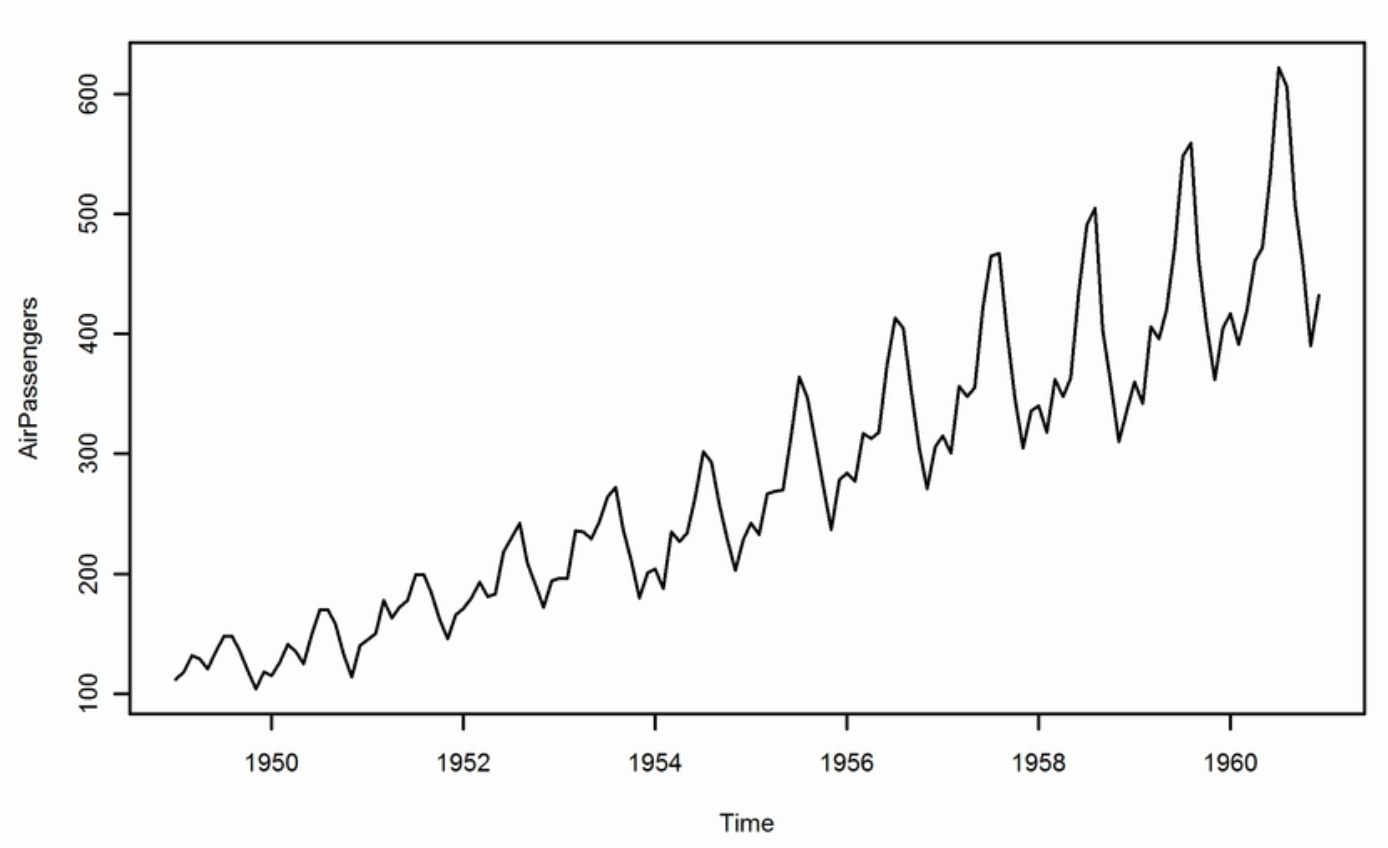  
- 계절성: 일정 주기에 따라 반복적으로 나타나는 데이터의 변동 -> 예측 모델링 가능
- 추세: 시간의 흐름에 따라 나타나는 장기적인 증가/감소 경향 -> 전반적인 방향성 파악 가능

### [자기 상관성]
- 자기자신끼리 상관관계 O
- 시간이 지남에 따라 값들 간에 일정한 패턴이나 반복 존재 -> 과거 데이터를 바탕으로 미래 예측 가능
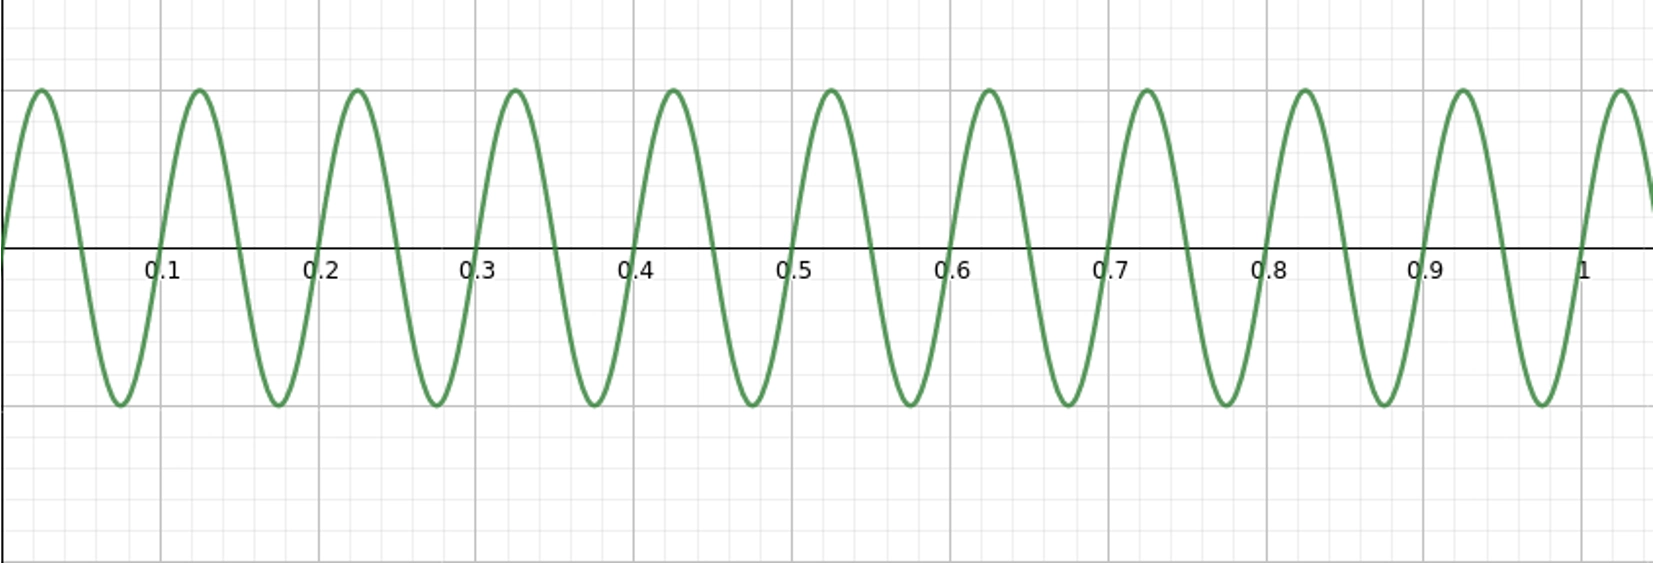  
-> 0.1마다 같은 값을 가지는 자기상관성이 높은 데이터
> 시계열 데이터는 일반적인 회귀 분석을 사용하면 문제가 생긴다  

- **오차항 독립성 가정 위반**: 오차항 간의 상관관계 O -> 통계적 추론 왜곡
- **허위 상관관계** 문제: 실제로 두 변수 간 인과관계는 없지만 공통된 시간 추세로 인해 높은 상관관계 나타남 -> 각 시계열 변수에서 추세를 제거한 후 분석
- **예측의 어려움** & **모델 복잡성 증가**
    - 자기 상관성으로 인해 잔차가 시간에 따라 패턴을 가져 미래값 예측이 왜곡, 예측 오차 누적되어 신뢰도 하락
    - 단순 회귀모형이 아닌 *AR, ARIMA 등의 시계열 모델* 필요

## 시계열 데이터의 분석 요인
- 추세 요인: 데이터 전반에 걸쳐 **시간에 따라 지속적으로 증가/감소**하는 경향. 계속 증가/감소하는 선형 그래프 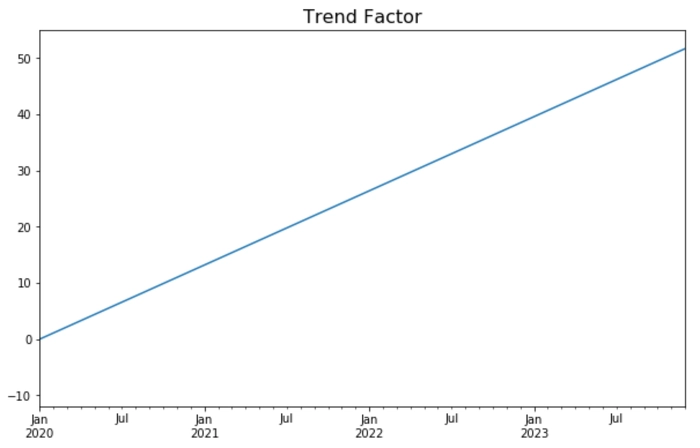  
- 계절 요인: **일정한 주기로 반복**되는 패턴. 주기적인 변동을 갖는 그래프 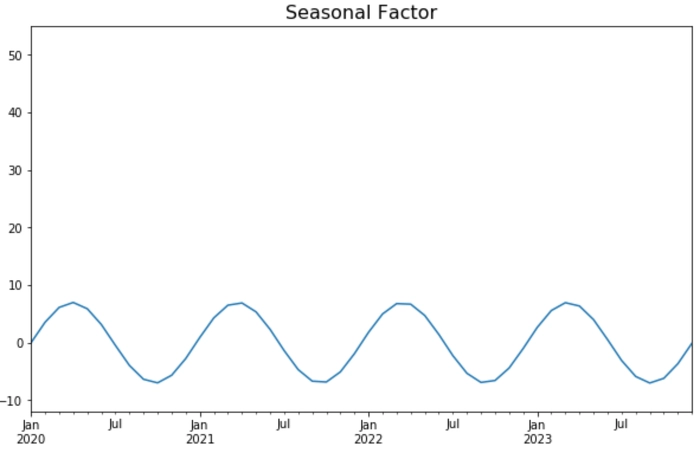  
- 순환 요인: 계절성보다 더 길고 **불규칙한 주기로 반복**되는 변동. 길게 상승/하강을 반복하는 파형 그래프 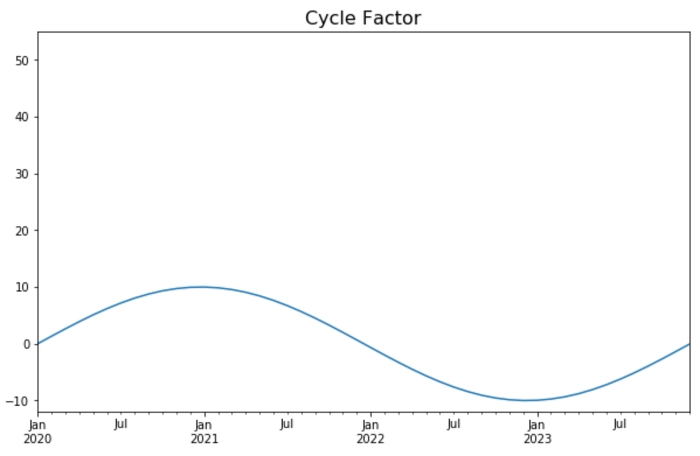
- 불규칙 요인: 추세, 계절성, 순환성을 모두 제거한 뒤 남은 예측 불가능한 변동. 불규칙한 변동을 나타내는 그래프 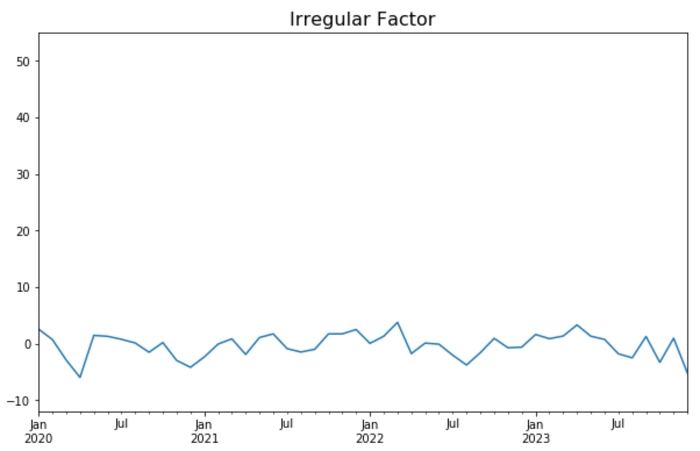

# **시계열 데이터 전처리**
## 결측치/이상치 탐지 및 처리
### [결측치]
- **특정 시점에서 값이 측정되지 않았거나 누락된 상태** ->추세, 계절성 왜곡
- 결측치 삭제: 결측치 제거를 통해 처리 -> 시간 흐름의 연속성 깨짐
- 단순 대치: 결측치를 평균, 중앙값, 최빈값, 0으로 대체 -> 패턴 왜곡 가능성
- **보간법**: 주어진 데이터 포인트의 값을 사용해 **두 개 이상의 데이터 포인트 사이에서 누락된 값을 추정**하는 수학적 기법
    - 선형 보간법: 두 점을 연결한 직선 방정식을 사용해 그 사이의 값을 추정. 데이터가 선형적일 때 적합
    - 다항식 보간법: 주어진 데이터 포인트를 모두 통과하는 당항식 함수로 근사하여 값 추정. 데이터가 비선형적일 때 적합. 고차 다항식은 과적합 유발 가능
    - 스플라인 보간법: 구간별 다항식을 사용해 각 구간에서 보간 수행. 곡선형 데이터에 유용
    - 조각별 상수 보간법: 각 구간에서 동일한 상수값을 유지하여 보간 수행. forward fiil / backward fill / 최근접 이웃 보간

### [이상치]
- **값이 측정되었으나, 측정된 값이 일반적이지 않은 경우** -> 측정 오류이거나 실제로 특이한 이벤트일 수 O
- 탐지 방법
    - **IQR Rule-based Anomaly Detection**: **주기성이 없거나 비교적 안정적인 구간의 값**들에서 이상치를 탐지할 때 사용. 구간별로 나눠서 IQR 계산 시 추세 영향 줄일 수 O 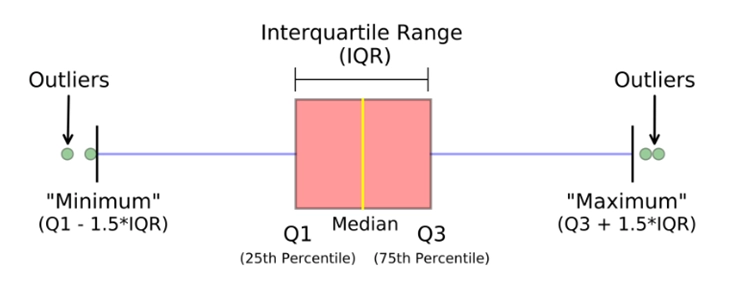  
    -> 이 조건 만족 시 이상치로 간주
        - 단순하고 명확한 해석, 빠름
        - 추세나 계절성이 강한 시계열에는 부적합
    - **Z-score**: **계절성/추세가 약하거나 값의 변동폭이 일정한 시계열**에 효과적. 구간별로 나눠서 계산 시 추세 영향 줄일 수 O. $$Z=(x−μ)/σ$$
        -> 특정 값이 평균으로부터 몇 표준편차만큼 떨어져 있는지 표현. Z-score가 특정 임계값을 넘으면 이상치로 간주
        - 계산이 간단하고 빠름, 직관적
        - 정규분포 가정에 민감. 비정상 시계열에서는 안정적인 임계값 설정이 어려움
    - **STL 분해**: 잔차가 특정 임계값 초과 시 이상치 탐지. 계절성이나 추세가 뚜렷한 시계열에 적합 $$ X_t(데이터) = T_t(추세) + S_t(계절성) + R_t(잔차) $$
        - 계절성과 추세를 제거하고 진짜 이상치만 탐지 가능, 비정상 시계열에도 유연하게 적용 가능
        - 계산 비용이 크고 매우 긴 시계열에는 파라미터 튜닝 필요
- 탐지 모델
    - **분류 및 회귀 트리(CART)**: 데이터를 분할하여 예측값을 산출했을 때, 예측 오차가 일정 임계값 이상인 지점을 이상치로 간주 -> 과거 구간의 값을 입력으로 하여 다음 시점 값 예측, **예측 오차 기반으로 이상 판단**
        - 비선형 관계를 잘 포착하고 다변량 시계열에도 적용 가능
        - 노이즈가 많은 경우 과적합 위험. 트리의 깊이에 따라 민감도 상이
        > 트리?  
        
        CART 분석에서 회귀 트리를 이용할 경우, 예측한 값과 실제 값의 차이가 클수록 이상으로 탐지
    - **클러스터링 기반 이상 탐지**: 이상치는 클러스터 중심에서 멀리 떨어진 outlier cluster나 소수 클러스터로 나타남 -> 시계열의 특징 추출 후 각 시점을 벡터로 표현해서 클러스터링 수행, **중심으로부터의 거리나 군집 밀도를 기준으로 이상치 판단**
        - 복잡한 패턴의 데이터나 다변량일 때 유용, 사전 분포 가정 필요 X
        - 하이퍼파라미터에 민감, 순서 정보 반영 X
    - **오토 인코더**: 인공신경망 기반 비지도 학습 모델로, 정상 데이터에 대한 특징을 학습하고 학습된 모델에 데이터를 입력했을 때 **재구성한 결과와 학습된 정상 특징과의 차이점을 비교하여 이상 여부 판단** -> LSTM 오토 인코더 사용 시 시간적 의존성까지 학습 가능. **sliding window로 시계열 구간 학습, 테스트 구간의 복원오차로 이상 탐지** 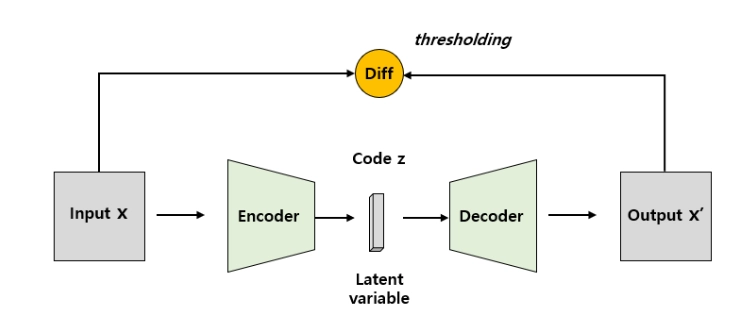  
        - 복잡한 비선형 패턴 학습 가능, 다변량 시계열에 강력
        - 학습 데이터가 많아야 하고 모델 해석 어려움, 파라미터 튜닝 까다로움
- 처리 방법: 삭제, 단순 대치, 보간

## EDA (평활화)
- 시계열 데이터에서 **노이즈를 줄이고**, 전체적인 흐름이나 추세를 더 명확하게 파악하기 위해 **데이터를 부드럽게 만드는 기술**
- **이동평균**(Moving Average, MA) 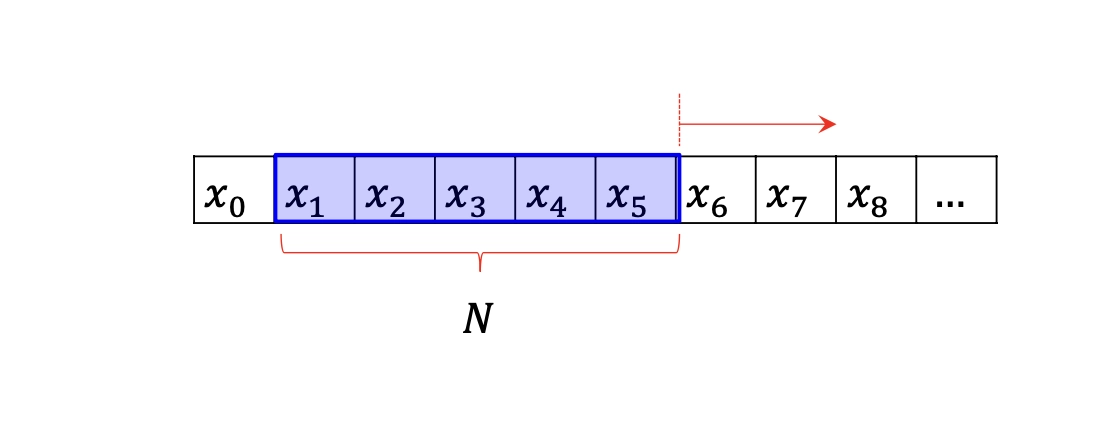  
    - N = Moving Window의 길이 -> N이 클수록 긴 기가의 데이터를 평균에 포함하므로 노이즈가 더 많이 제거, 매끄러운 곡선 생성 가능
    - 시계열의 부분집합으로 평균을 구하여 평활화 효과를 얻는 방법
    - 윈도우 내의 평균 계산
    - 목적: 노이즈 제거, 추세 파악, 예측의 기초 자료
    - 유형
        | 종류 | 설명 | 사용 | 식
        | --- | --- | --- | --- |
        | 단순 이동평균 (SMA) | 특정 기간의 데이터를 단순 평균으로 계산 | 변동이 심하지 않고 비교적 안정적인 시계열 | $SMA_t = \frac{1}{n} \sum_{i=0}^{n-1} Y_{t-i}$ |
        | 가중 이동평균(WMA) | 최근 값에 더 큰 가중치 부여 | 최근 데이터가 더 중요한 상황 | $WMA_t = \frac{\sum_{i=0}^{n-1} w_i Y_{t-i}}{\sum_{i=0}^{n-1} w_i}$ |
        | 지수 이동평균(EMA) | 최근 데이터에 더 많은 가중치 부여, **지수적으로 감소하는 가중치** 적용  | 최근 값에 매우 빠르게 반응해야 하는 시계열 | $EMA_t = \alpha Y_t + (1-\alpha) EMA_{t-1}\\$ |

## 요소분해
- 주어진 시계열 데이터를 개별 성분(추세성, 계절성, 순환성, 불규칙성)으로 분해 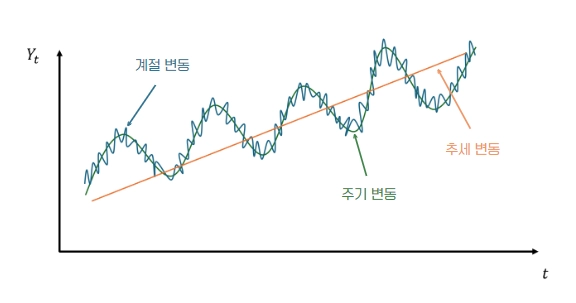  
$$ Y_t = f(T_t(추세), S_t(계절), C_t(순환), R_t(불규칙))$$
- 일반적으로 순환성은 장기간에서만 고려 -> C_t = 0
> 요소 분해는 왜 하나요?  

시계열 데이터는 **추세, 계절성, 순환성, 불규칙 성 등 다양한 변동**이 결합되어 있으므로 이걸 다 분리하면 **각각의 패턴을 명확히 이해**할 수 있다. 이에 따라 예측, 이상 탐지 분석 등의 작업을 더욱 정교하게 가능!

### [분해 모형 - 수학적 형태로의 분해]
- 가법 모형: **시계열 관측값은 변동 요인들의 가법(+)으로 설명**될 수 있다 가정. 각 변동 요인들이 독립적으로 더해지며, 모든 요소의 영향 일정. **계절성의 진폭이 일정할 때** 적합 $$y_t = T_t + S_t + R_t$$
- 승법 모형: **시계열 관측값은 변동 요인들의 승법(\*)으로 설명**될 수 있다 가정. 추세가 커질수록 계절성이나 불규칙성의 효과도 비례해서 커짐. 진폭이 시간에 따라 달라질 때 적합 $$
y_t = T_t * S_t * R_t$$

### [분해 방법 - 구현 알고리즘]
- seasonal decompose: 이동평균으로 추세 추출 (detrending)-> 잔여 성분에서 계절성 분리 
    - 작동 방식
        1. 추세 추출: 중심 이동평균 적용
        2. Detrending: 원래 데이터에서 추세 제거
        3. 계절성 추정: 2에서 만든 시계열에서 동일한 계절 인덱스에 해당하는 값들의 평균을 취해 계절성 도출. 연간 평균이 0이 되도록 정규화
        4. 잔차 산출

- STL: LOESS(Locally Estimated Scatterplot Smoothing) 기반 분해. 추세와 계절성이 시간에 따라 변화하는 경우에도 유연하게 포착할 수 있으며, 이상치에 강건한 분해가 가능
    - 작동 방식: 이중 루프 구조
        - inner: 통상 2회 반복  
            1. 추세 제거
            2. Cycle-subseries 추출 후 각 subseries에 LOESS 적용
            3. Low-pass filter로 저주파 성분 제거
            4. 계절 성분 확정
            5. 계절성 제거
            6. LOESS로 추세 갱신
        - outer: 잔차 크기 기준으로 강건성 가중치를 부여해 이상치의 영향력을 줄인 후 inner loop 재실행

# **정상성 판단**
## 정상성이란?
- 정상성: 시계열 데이터의 평균, 분산 등 통계적 특성이 시간에 따라 일정한 수준으로 유지되는 것
- 정상성이 있으면 과거 패턴을 바탕으로 미래 예측이 가능해서 통계 모델링에 적용하기 좋다

## 강한 정상성과 약한 정상성
- 강한 정상성: 시간을 언제로 잡든 데이터의 확률 분포 자체가 동일
    - 특징: 평균, 분산 뿐만 아니라 데이터의 왜도, 첨도 등 모든 통계적 특성이 일정
    - 한계: 현실의 데이터는 잡음과 외부 요인이 항상 존재하기 때문에 이런 상태는 거의 존재 X
- 약한 정상성: 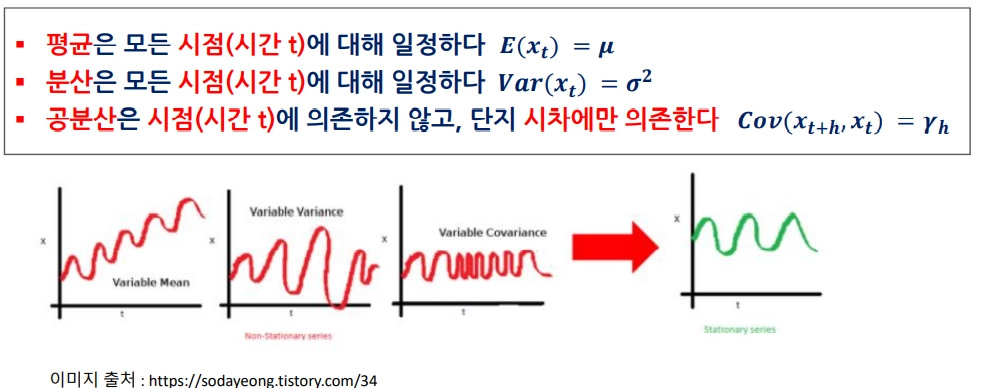  
    - 특징: 전체 확률 분포는 변할 수 있으나 평균, 분산, 자기공분산은 변화지 X
    > 공분산이 시차에 의존한다?  

    언제 측정하는냐가 아닌, 얼마나 떨어졌느냐가 중요하다는 것

## 정상성 판단하기
### [시각적 판단]
- 정상 데이터: 그래프가 기준선(평균)을 중심으로 일정한 폭으로 진동하는 형태
- 비정상 데이터: 추세성 존재(시간에 따라 데이터가 지속적으로 상승/하락), 계절성 존재(1년 등의 특정 주기로 패턴 반복)
    - 추세가 뚜렷한 시계열은 차분(differencing)을 통해 해석 가능

### [통계적 검정]
- 단위근: **과거 충격이 영구적으로 누적**되는 특성. 시계열이 랜덤하게 움직이게 만들어 평균으로 회귀하지 않고, 분산이 시간에 따라 증가하며 예측이 어려워짐
    - **시계열 모델의 특성방정식에서 근이 1인 경우 해당 시계열은 단위근을 가짐 = 비정상 시계열** $$y_t = \alpha y_{t-1} + e_{t}$$
    - 위 식에서 알파 = 자기회귀 계수 = 특정방정식의 근
    - 알파 = 0: 과거 값의 영향 X. 오차항 e_t만으로 시계열 생성 -> 완전한 정상성
    - |알파| < 1: 현재 값이 이전 값의 영향(자기상관)을 받지만, 시간이 지날수록 과거 충격의 영향 희석 -> 결과적으로 평균 수준으로 돌아옴 -> 정상 시계열
    - **알파 = 1**: y_t = 지금까지의 오차 누적 -> **랜덤 워크** -> 비정상 시계열
- 단위근 검정
    | 구분 | ADF 검정(단위근 검정) | KPSS 검정(정상성 검정) |
    | --- | --- | --- |
    | 가정 | 데이터의 비정상성 가정 | 데이터의 정상성 가정 |
    | 귀무가설($H_0$) | 단위근 존재 → 비정상 시계열 | 단위근 없음 → 정상 시계열 |
    | 대립가설($H_1$) | 단위근 없음 → 정상 시계열 | 단위근 존재 → 비정상 시계열 |
    | 정상성 판정 기준 | p-value < 유의수준($H_0$ 기각) | p-value > 유의수준($H_0$ 채택) |
    | 확정적 추세 존재시 문제점 | 추세를 단위근으로 착각해 비정상으로 오판하기 쉬움 | 추세 때문에 평균이 변하므로 비정상으로 판단함 |
    | 결과가 상충될때의 의미 | 시계열 데이터에 확정적 추세가 있음을 의심할 수 있음 | ADF 검정과 동일한 결론 공유 |
    | 해결 방법 | 모델에 추세항 추가 → ADF(Trend) | 모델에 추세항 추가 → KPSS(Trend) |  

    - 결과 해석

    | ADF | KPSS | 진단 | 다음 액션 |
    | --- | --- | --- | --- |
    | 정상 | 정상 | 정상 시계열 | 그대로 모델링 가능 |
    | 비정상 | 비정상 | 단위근 존재(확률적 추세) | 차분 적용 |
    | 비정상 | 정상 | 확정적 추세 의심 | 추세 제거 or 추세항 모델링 |

## 정상성 확보 방법
- 추세 제거: 시계열이 지속적으로 증가/감소할 때
    - **차분**: 연이은 관측값들의 차이 계산 -> **평균의 정상성 확보**
    - 시계열 데이터에서 **한 시점의 값과 그 이전 시점의 값을 차분**하여 변화량을 계산
    - 대부분의 비정상적 시계열은 값이 누적되는 *누적과정*이므로 누적값을 빼주면 정상적 시계열 도출 가능
        - 1차 차분: $y'_t = y_t - y_{t-1}$ -> 추세 제거
        - 2차 차분: $$\begin{align*}y''_t &= y'_t - y'_{t-1} \\      &= (y_t - y_{t-1}) - (y_{t-1} - y_{t-2}) \\      &= y_t - 2y_{t-1} + y_{t-2}\end{align*}$$
        - 역차분: 차분된 데이터에 이전 시점 값을 더해서 원래 값으로 복원
- 계절성 제거: 시계열이 주기적인 패턴을 가질 때
    - 계절 차분: t시점의 y값에서 t-m시점의 y값을 빼는 것 (m: 주기의 길이) $$y_t^* = y_t - y_{t - m}$$
    - 계절성 제거 시 백색소음과 같은 형태의 데이터로 변환 -> 완전히 랜덤한 데이터(이전 데이터와 무관)
- 분산 안정화: 시계열의 변동 폭이 점점 커지거나 작아질 때
    - 로그변환: 분산의 정상성을 확보하기 위한 방법. 비율적인 변화 강조, 실제 변화폭은 줄어서 분산이 일정해짐. but 음수나 0 처리 불가

# **단변량 시계열 분석**
## 안정적 시계열 분석
### [자기 회귀 모델(AR)]
- 자기 회귀: **과거 자신의 값들을 독립변수(x)로 삼아 현재 값(y)을 예측**하는 회귀 -> 시계열 데이터의 **자기상관성** 활용 $$AR(p):  y_{t}=c +\phi _1y_{t-1}+\phi_2y_{t-2}+...+\phi _py_{t-p}+\varepsilon _t$$
- p차 자기 회귀 모형: 과거 p개 시점의 데이터의 선형 조합을 이용해 예측하는 모델
$$AR(1):  y_{t}=c +\phi_1y_{t-1}+\varepsilon _t$$
- 현재 값($y_t$)은 1 시점 이전의 값($y_{t-1}$)의 영향을 받음

### [이동 평균 모델(MA)]
- **과거 시점의 잔차(ε)를 독립변수로 삼아 현재 값을 예측**하는 모델 -> 과거의 잘못 예측한 것(예측 오차, 충격)을 현재 시점에 반영 $$MA(q): y_t = \mu +\varepsilon _t+ \theta _1\varepsilon_{t-1}+\theta_2\varepsilon_{t-2}+...+\theta_q\varepsilon_{t-q}$$
- q차 이동 평균 모형: 과거 q개의 예측 오차의 선형 결합으로 예측하는 모델
$$MA(1):  y_{t}=\mu +\varepsilon _t+ \theta _1\varepsilon_{t-1}$$
- 현재 값($y_t$)은 1 시점 이전의 오차($ε_{t-1}$)의 영향을 받음

### [AR, MA 모델의 전제 조건]
- **정상성**: AR과 MA 모형은 안정적 시계열 분석으로 확률적 안정성을 전제로 추정 -> 모델 구조도 정상성 만족해야함
    - AR 모형의 정상성 조건: $1 - \phi_1 z - \phi_2 z^2 - \cdots - \phi_p z^p = 0$
        - 모든 해 z의 절댓값 > 1 -> AR 정상성 확보
    - MA 모형의 정상성 조건: 잔차(⇔ 백색 잡음)들은 정상성을 이미 만족하기 때문에 잔차들의 조합으로 이뤄진 MA 모형도 항상 정상성 만족
- **가역성**: **MA 모형을 AR 형태로 재표현할 수 있는지** 여부. 오차항은 직접 관찰이 불가능하기 때문에, 오차항도 관측 가능한 과거값으로 표현할 수 있어야 안정적
    - AR 모형의 가역성 조건: AR 모형은 처음부터 AR형태로 표현되어 있기 때문에 가역성 체크할 필요 X
    - MA 모형의 가역성 조건: $1 + \theta_1 z + \cdots + \theta_q z^q = 0$
        - 모든 해 z의 절댓값 > 1 -> MA 가역성 확보

### [ARMA 모형]
- Autoregressive Moving Average 모형: AR(p) 모형과 MA(q) 모형을 결합한 모형 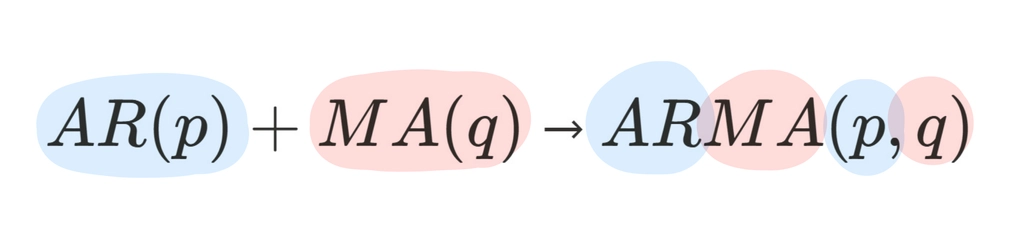
$$
Y_t = \phi_1Y_{t-1} + \phi_2Y_{t-2} + \cdots + \phi_pY_{t-p} + \varepsilon_t + \theta_1\varepsilon_{t-1} + \theta_2\varepsilon_{t-2} + \cdots + \theta_q\varepsilon_{t-q}
$$
- 과거 p개의 관측값 + 과거 q개의 오차를 활용해서 예측
- AR(p) 모형의 정상성, MA(q) 모형의 가역성 모두 만족해야함
- ARMA(p,0) -> AR(p)와 동일
- ARMA(0,q) -> MA(q)와 동일
- ARMA(0,0) -> 백색 잡음 모델과 동일

### [차수 결정 방법]
- 두 그래프를 통해 현재 값이 과거 값과 어떤 관계가 있는지 파악하고 이를 통해 AR, MA, ARMA의 적절한 차수(p, q)를 결정
- **자기 상관계수**(Auto Correlation Function, ACF): ARMA(p, q)모형에서 사용할 q개의 오차 결정 방법. 두 시점 사이의 상관 관계 파악 (**간접 영향 포함**)
- **부분 자기 상관 계수** (Partial Autocorrelation Function, PACF): ARMA(p, q) 모형에서 사용할 p개의 시점 결정 방법. **두 시점 사이의 직접적인 영향만 파악**
-   | **ACF 그래프** 모습 | **PACF 그래프** 모습 | **선택 모델 및 차수** |
    | --- | --- | --- |
    | 천천히 감소 or 진동 감소 | p+1 시점부터 0에 근접 | **AR(p) (= ARMA(p, 0)),** p = 절단 시점 |
    | q+1 시점부터 0에 근접 | 천천히 감소 or 진동 감소 | **MA(q) (= ARMA(0, q)) ,** q= 절단 시점 |
    | q+1 시점부터 0에 근접 | p+1 시점부터 0에 근접 | **ARMA(p, q)** |

## 불안정 시계열 분석
### [ARIMA]
- Autoregressive Integrated Moving Average
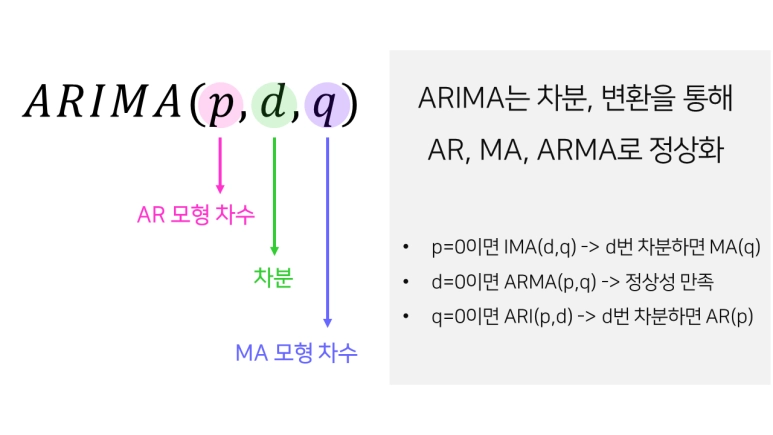  
$$ARMA(p, q) + \text{차분} \rightarrow ARIMA(p,d,q)$$
| 1. 백색잡음 | ARIMA(0,0,0) |
| --- | --- |
| 2. 자기회귀 | ARIMA(p,0,0) ⇔ AR(p) |
| 3. 이동평균 | ARIMA(0, 0, q) ⇔ MA(q) |
| 4. 랜덤워크 | 상수가 없는 ARIMA(0,1,0) |
| 5. 표류를 포함하는 랜덤워크 | 상수가 있는 ARIMA(0,1,0) |

- 랜덤 워크: $Y_t = Y_{t-1} + \varepsilon_t$ -> 현재 값을 예측할 때 가장 좋은 값은 어제의 값(변화량 = 0). 방향성 X
- 표류를 포함하는 랜덤워크: $Y_t = Y_{t-1} + \varepsilon_t + c$ -> 랜덤워크 모델에 상수항 추가, 방향성 존재. 시간이 흐를수록 상수항 누적

### [SARIMA]
- Seasonal ARIMA
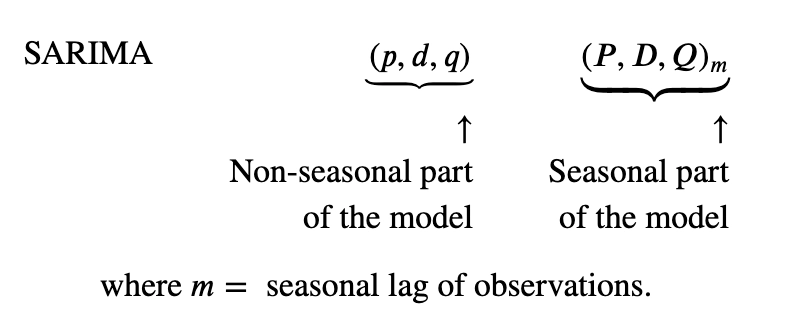
$$ARIMA(p,d,q) + \text{계절성(Seasonal) 차분} \\ \rightarrow SARIMA(p,d,q)(P, D, Q)_m$$
- 시계열 데이터의 계절성 처리 가능
- ARIMA 모델 + 계절성 변동

# **다변량 시계열 분석**
## VAR
- Vector Autoregression
- **자신의 과거 값과 다른 변수들의 과거 값을 함께 사용**하여 미래 예측
- 단변량 AR(1): $X_t = a₁ X_{t-1} + ε_t$ -> X는 자기 자신의 과거만 사용
- **다변량 VAR(1)**: $X_t = a_{11} X_{t-1} + a_{12} Y_{t-1} + ε_{x,t}$ , $Y_t = a_{21} X_{t-1} + a_{22} Y_{t-1} + ε_{y,t}$ -> X와 Y가 서로의 과거를 함께 사용
- 적합한 경우: 변수들이 서로 영향을 주고받을 때, 경제/금융 지표처럼 상호 의존성이 중요할 때
- 부적합한 경우: 변수가 너무 많을 때, 변수 간 관계가 명확하지 않을 때, 장기 예측이 필요할 때
- 분석 방법
    - **충격 반응 함수**(IRF, Impulse-Response Function): 한 변수의 충격이 다른 변수에 미치는 영향을 시간 흐름에 따라 분석
    - **예측오차 분산 분해**(Variance Decomposition): 예측 오차에 각 변수가 얼마나 기여하는지 분석

# **딥러닝을 활용한 시계열 분석**
## RNN 계열
- RNN, LSTM, GRU 사용
- 적합한 경우: 순차적 패턴이 중요할 때, 과거 정보가 미래 예측에 영향을 줄 때, 시계열 길이와 목적에 따라 모델 선택이 가능할 때
- 한계: 매우 긴 시계열은 학습 어려움, 병렬 처리 효율 낮음, Transformer 계열 대비 학습 속도 느림  

    | 모델 | 장점 | 단점 | 사용 예시 |
    | --- | --- | --- | --- |
    | **RNN** | 간단, 빠름 | 장기 의존성 학습 불가 | 짧은 시계열 (일주일 주가) |
    | **LSTM** | 장기 의존성 학습 가능 | 복잡, 느림 | 분기별 재무제표 예측 |
    | **GRU** | LSTM보다 빠름, 적당한 성능 | LSTM보다 장기 의존성 약함 | 실시간 센서 데이터 예측 |

## Transformer
- Informer(장기 예측 특화): 불필요한 연산을 줄여 계산 복잡도를 낮춘 모델 -> 매우 긴 시계열 데이터 처리에 강함
- Autoformer(주기성 포착 특화):  시계열의 전통적 기법인 요소 분해(추세/계절성) 개념을 딥러닝 구조에 직접 결합한 모델. 연간 계절성 등 주기 패턴이 뚜렷하게 나타나는 판매량 예측에 압도적인 성능
- TFT (Temporal Fusion Transformer): 과거 데이터뿐만 아니라 다양한 외부 변수(날씨, 휴일 유무 등)를 섞어서 예측 가능. 어떤 변수가 예측에 가장 중요했는지 어텐션 스코어를 통한 해석이 가능해, 설명력이 중요한 유통/비즈니스 수요 예측에 가장 많이 쓰임

## Foundatioin Model
- 거대한 데이터로 사전학습하여 다양한 문제를 해결할 수 있는 범용 모델
- 특징: 특정 문제 전용 X (범용적), 사전 학습 후 파인튜닝으로 특화
- 유형
    | 유형 | 설명 | 예시 |
    | --- | --- | --- |
    | **LLM 기반 모델** | LLM을 시계열 분석에 활용 | Prompting, Fine-tuning |
    | **시계열 전용 Foundation Model** | 시계열 데이터로 사전 학습된 범용 모델 | TimeGPT, TimesFM, Moirai, Chronos |
- LLM 기반 모델 활용 방식
    - Without Adaption: LLM이 이미 시계열 지식을 가지고 있다고 가정 -> 프롬프트 엔지니어링에 집중
    - Adapt LLM: LLM을 시계열 데이터로 파인튜닝
    - Adapt to LLM: 시계열을 텍스트로 변환 후 LLM 활용